
# Stock Price Movement Predictor
Predicting next-day price direction (Up or Down) using historical daily OHLCV data and technical indicators.


In [1]:

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from ta import add_all_ta_features
from ta.utils import dropna
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange, BollingerBands
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


## 1. Data Fetching & Preprocessing
Downloading historical data for S&P 500 ETF (SPY).

In [2]:

ticker = "SPY"
data = yf.download(ticker, start="2018-01-01", end="2024-01-01")
print(f"Downloaded {len(data)} rows for {ticker}")

# Flatten columns if multi-index (common in newer yfinance versions)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]
    
data.head()


[*********************100%***********************]  1 of 1 completed

Downloaded 1509 rows for SPY


,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,235.954300,235.989424,234.751575,235.137855,86655700
2018-01-03,237.446716,237.595972,236.121073,236.121073,90070400
2018-01-04,238.447449,238.930312,237.508112,238.087532,80636400
2018-01-05,240.036560,240.159453,238.746040,239.237664,83524000
2018-01-08,240.475601,240.633618,239.650369,239.940066,57319200


## 2. Leak-Free Target Construction
Create a binary target: 1 if tomorrow's Close > today's Close, 0 otherwise.

In [3]:

# Target variable: 1 if next day's close is strictly greater than today's close, else 0
# We explicitly use shift(-1) so today's row gets tomorrow's price direction.
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Drop the last row because its target will be NaN (no 'tomorrow' data available)
data.dropna(subset=['Target'], inplace=True)

# Print a sample to verify no leak:
sample_check = data[['Close', 'Target']].tail(5)
print("Verifying Target Construction (Leak-Free Check):")
print("Notice how today's Target corresponds to whether tomorrow's Close is higher.")
print(sample_check)


Verifying Target Construction (Leak-Free Check):
Notice how today's Target corresponds to whether tomorrow's Close is higher.
                 Close  Target
Date                          
2023-12-22  459.779938       1
2023-12-26  461.721375       1
2023-12-27  462.556183       1
2023-12-28  462.730957       0
2023-12-29  461.391327       0


## 3. Feature Engineering
### 3.1 Raw Features

In [4]:

# Raw Features
data['Return'] = data['Close'].pct_change()
data['High-Low'] = data['High'] - data['Low']
data['Volume_Change'] = data['Volume'].pct_change()

# Drop NaNs generated by pct_change
data.dropna(inplace=True)


### 3.2 Engineered Features (Technical Indicators)
Calculated using the `ta` library.

In [5]:

# Technical Indicators using `ta`

# Simple Moving Average (SMA) - 20 days
sma = SMAIndicator(close=data["Close"], window=20)
data['SMA_20'] = sma.sma_indicator()

# Exponential Moving Average (EMA) - 20 days
ema = EMAIndicator(close=data["Close"], window=20)
data['EMA_20'] = ema.ema_indicator()

# Relative Strength Index (RSI) - 14 days
rsi = RSIIndicator(close=data["Close"], window=14)
data['RSI_14'] = rsi.rsi()

# Moving Average Convergence Divergence (MACD)
macd = MACD(close=data["Close"])
data['MACD'] = macd.macd()
data['MACD_Signal'] = macd.macd_signal()

# Average True Range (ATR) - 14 days
atr = AverageTrueRange(high=data["High"], low=data["Low"], close=data["Close"], window=14)
data['ATR_14'] = atr.average_true_range()

# Bollinger Bands - 20 days
bb = BollingerBands(close=data["Close"], window=20, window_dev=2)
data['BB_High'] = bb.bollinger_hband()
data['BB_Low'] = bb.bollinger_lband()

# Drop rows with NaNs caused by the rolling windows of technical indicators
data.dropna(inplace=True)
print(f"Data shape after feature engineering: {data.shape}")


Data shape after feature engineering: (1475, 17)


## 4. Time-Based Train-Test Split
Chronological split to prevent look-ahead bias.

In [6]:

raw_features = ['Close', 'Volume', 'Return', 'High-Low', 'Volume_Change']
eng_features = ['Close', 'Volume', 'Return', 'High-Low', 'Volume_Change', 
                'SMA_20', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 
                'ATR_14', 'BB_High', 'BB_Low']

X_raw = data[raw_features]
X_eng = data[eng_features]
y = data['Target']

# Chronological split (80% train, 20% test)
split_idx = int(len(data) * 0.8)

X_raw_train, X_raw_test = X_raw.iloc[:split_idx], X_raw.iloc[split_idx:]
X_eng_train, X_eng_test = X_eng.iloc[:split_idx], X_eng.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training data: {X_raw_train.shape[0]} rows (Dates: {X_raw_train.index[0].date()} to {X_raw_train.index[-1].date()})")
print(f"Testing data: {X_raw_test.shape[0]} rows (Dates: {X_raw_test.index[0].date()} to {X_raw_test.index[-1].date()})")

# Verify no date overlap (Leak check)
assert X_raw_train.index[-1] < X_raw_test.index[0], "Data Leakage: Train set overlaps or is after test set!"


Training data: 1180 rows (Dates: 2018-02-21 to 2022-10-26)
Testing data: 295 rows (Dates: 2022-10-27 to 2023-12-29)


## 5. Scaling
Fitting the scaler *only* on the training data.

In [7]:

# Scaling fit ONLY on training data to prevent look-ahead bias
scaler_raw = StandardScaler()
X_raw_train_scaled = scaler_raw.fit_transform(X_raw_train)
X_raw_test_scaled = scaler_raw.transform(X_raw_test)

scaler_eng = StandardScaler()
X_eng_train_scaled = scaler_eng.fit_transform(X_eng_train)
X_eng_test_scaled = scaler_eng.transform(X_eng_test)


## 6. Class Balance Analysis

In [8]:

# Class distribution
train_counts = y_train.value_counts(normalize=True) * 100
test_counts = y_test.value_counts(normalize=True) * 100

print("Class Balance (Up=1, Down=0)")
print("Training Set:")
print(train_counts)
print("\nTest Set:")
print(test_counts)


Class Balance (Up=1, Down=0)
Training Set:
Target
1    54.576271
0    45.423729
Name: proportion, dtype: float64

Test Set:
Target
1    53.559322
0    46.440678
Name: proportion, dtype: float64


## 7. Naive Baselines
Persistence and Majority-Class baselines.

In [9]:

# 1. Persistence Baseline
# Predict tomorrow's direction will be the same as today's direction
# Today's direction: 1 if Close_t > Close_{t-1} else 0
persistence_preds = (X_raw_test['Close'] > X_raw_test['Close'].shift(1)).astype(int)
# Handle the first element properly
persistence_preds.iloc[0] = (X_raw_test['Close'].iloc[0] > X_raw_train['Close'].iloc[-1]).astype(int)

# 2. Majority Class Baseline
# Find the most frequent class in the training set
majority_class = y_train.mode()[0]
majority_preds = np.full(shape=y_test.shape, fill_value=majority_class)

acc_persistence = accuracy_score(y_test, persistence_preds)
acc_majority = accuracy_score(y_test, majority_preds)

print(f"Persistence Baseline Accuracy:   {acc_persistence:.4f}")
print(f"Majority-Class Baseline Accuracy: {acc_majority:.4f}")


Persistence Baseline Accuracy:   0.4915
Majority-Class Baseline Accuracy: 0.5356


## 8. Model Training & Evaluation
Comparing Random Forest on raw vs engineered features.

In [10]:

# Train Random Forest on Raw Features
rf_raw = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_raw.fit(X_raw_train_scaled, y_train)
preds_raw = rf_raw.predict(X_raw_test_scaled)

# Train Random Forest on Engineered Features
rf_eng = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_eng.fit(X_eng_train_scaled, y_train)
preds_eng = rf_eng.predict(X_eng_test_scaled)

# Collect metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

results = [
    get_metrics(y_test, persistence_preds, 'Persistence Baseline'),
    get_metrics(y_test, majority_preds, 'Majority Class Baseline'),
    get_metrics(y_test, preds_raw, 'RF (Raw Features)'),
    get_metrics(y_test, preds_eng, 'RF (Engineered Features)')
]

results_df = pd.DataFrame(results)
display(results_df)

print("\nConfusion Matrix - RF (Engineered Features):")
print(confusion_matrix(y_test, preds_eng))


,Model,Accuracy,Precision,Recall,F1-Score
0,Persistence Baseline,0.491525,0.525316,0.525316,0.525316
1,Majority Class Baseline,0.535593,0.535593,1.000000,0.697572
2,RF (Raw Features),0.522034,0.536797,0.784810,0.637532
3,RF (Engineered Features),0.508475,0.527197,0.797468,0.634761



Confusion Matrix - RF (Engineered Features):
[[ 24 113]
 [ 32 126]]


## 9. Visualization
Predicted vs. Actual directional movement.

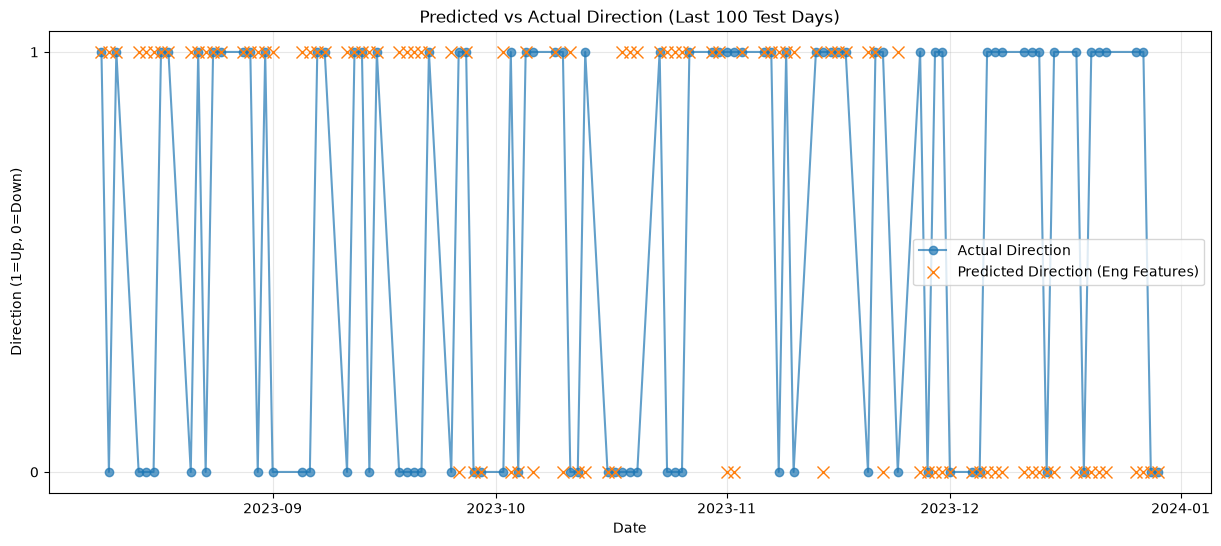

In [11]:

plt.figure(figsize=(15, 6))
# We plot a subset to make it readable, e.g., the last 100 days of the test set
subset_y_test = y_test[-100:]
subset_preds_eng = preds_eng[-100:]

plt.plot(subset_y_test.index, subset_y_test.values, label='Actual Direction', marker='o', linestyle='-', alpha=0.7)
plt.plot(subset_y_test.index, subset_preds_eng, label='Predicted Direction (Eng Features)', marker='x', linestyle='', markersize=8)
plt.title('Predicted vs Actual Direction (Last 100 Test Days)')
plt.ylabel('Direction (1=Up, 0=Down)')
plt.xlabel('Date')
plt.yticks([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
